/tmp/ipykernel_3596/1098795427.py:68: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


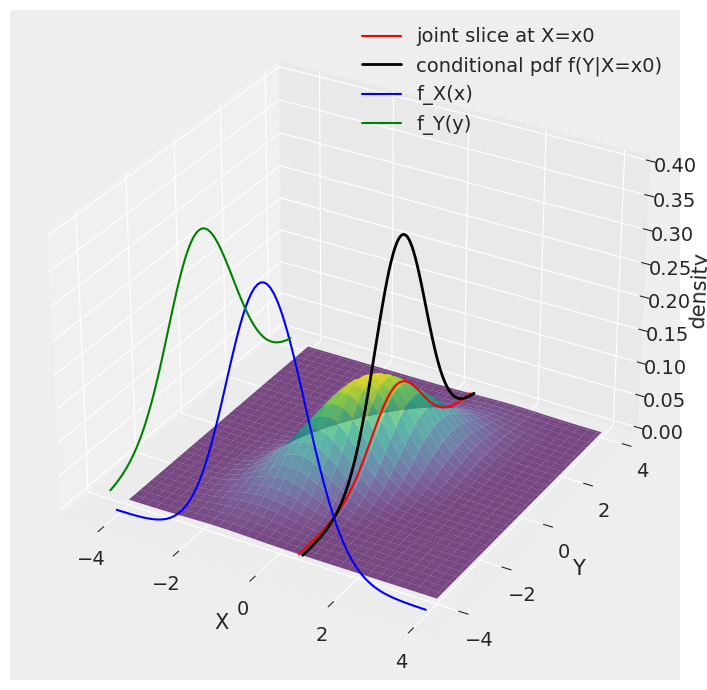

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# 1. 2차원 정규분포 정의
mean = np.array([0, 0])
cov = np.array([[1, 0.8],
                [0.8, 2]])
rv = multivariate_normal(mean, cov)

# 2. grid 위에서 joint pdf 계산
x = np.linspace(-4, 4, 101)
y = np.linspace(-4, 4, 101)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = rv.pdf(pos)

# 3. figure / 3D axes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 3-1. joint pdf 3D surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)

# 4. 조건부 분포 (예: X = x0 에서의 Y|X=x0)
x0 = 0.5
# grid에서 x0에 가장 가까운 index
ix = np.argmin(np.abs(x - x0))
fX = Z.sum(axis=0) * (y[1] - y[0])  # 주변분포 f_X(x) 근사
fX_x0 = fX[ix]
cond_Y = Z[:, ix] / fX_x0          # f_{Y|X}(y|x0)

# 4-1. 조건부 분포 곡선을 3D joint 위에 겹쳐 그리기
ax.plot(
    np.full_like(y, x0),  # X = x0
    y,
    rv.pdf(np.column_stack([np.full_like(y, x0), y])),  # joint 위의 단면
    color='red',
    label='joint slice at X=x0'
)

# 4-2. 조건부 분포를 Z 축 조금 띄워서 별도로 표시 (시각적 분리용)
ax.plot(
    np.full_like(y, x0 + 0.1),  # 약간 옆으로
    y,
    cond_Y,
    color='black',
    linewidth=2,
    label='conditional pdf f(Y|X=x0)'
)

# 5. 주변분포 f_X(x), f_Y(y) (바닥/옆면에 투영)
# f_X(x): Y에 대해 적분
fX = Z.sum(axis=0) * (y[1] - y[0])
# f_Y(y): X에 대해 적분
fY = Z.sum(axis=1) * (x[1] - x[0])

# 바닥 z=0 평면에 f_X(x) line
ax.plot(x, np.full_like(x, y.min() - 0.5), fX, color='blue', label='f_X(x)')
# 옆면 z=0 평면에 f_Y(y) line
ax.plot(np.full_like(y, x.min() - 0.5), y, fY, color='green', label='f_Y(y)')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('density')
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_3596/1957962281.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


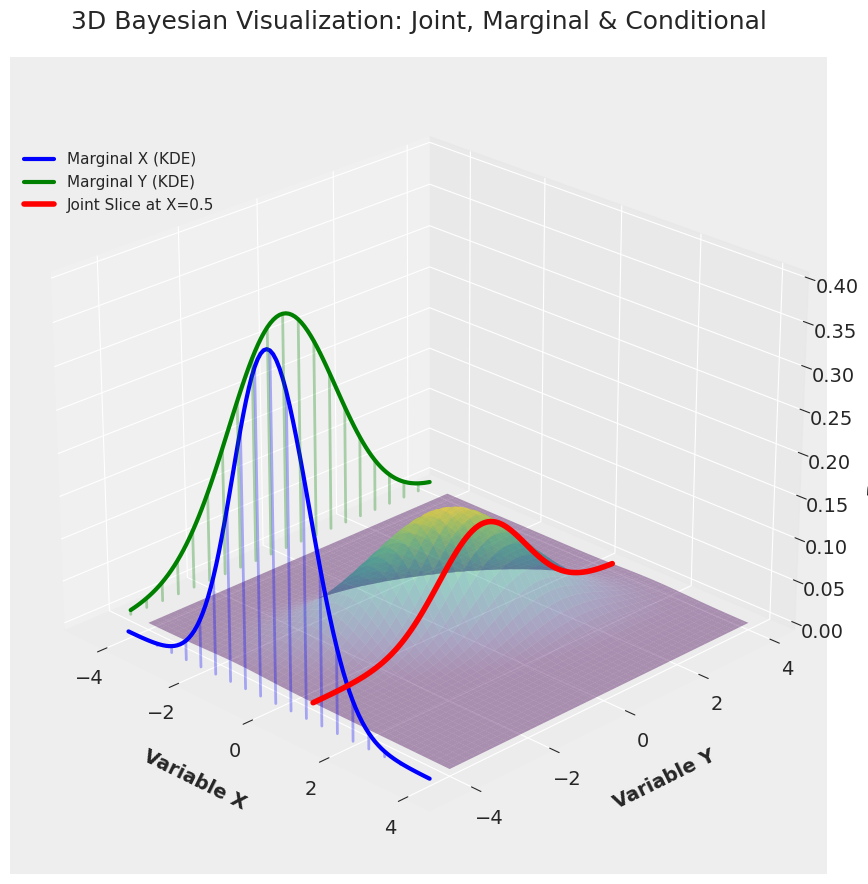

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import multivariate_normal

# 1. 설정 및 데이터 생성
plt.rcParams.update({'font.size': 12}) # 전체 글자 크기 상향
mean = np.array([0, 0])
cov = np.array([[1, 0.8], [0.8, 2]])
rv = multivariate_normal(mean, cov)

x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = rv.pdf(pos)

# 2. Figure 설정
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# 3. Joint PDF Surface (투명도 조절로 내부가 보이게)
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.4, antialiased=True)

# 4. 주변 분포 (Marginal) 시각화 - 히스토그램 & KDE 스타일
fX = Z.sum(axis=0) * (y[1] - y[0]) # f_X(x)
fY = Z.sum(axis=1) * (x[1] - x[0]) # f_Y(y)

# X축 방향 Marginal (Y의 최소값 벽면에 투영)
y_min = y.min() - 0.5
ax.plot(x, np.full_like(x, y_min), fX, color='blue', lw=3, label='Marginal X (KDE)')
# 히스토그램 느낌의 막대 추가
for i in range(0, len(x), 5):
    ax.plot([x[i], x[i]], [y_min, y_min], [0, fX[i]], color='blue', alpha=0.3, lw=2)

# Y축 방향 Marginal (X의 최소값 벽면에 투영)
x_min = x.min() - 0.5
ax.plot(np.full_like(y, x_min), y, fY, color='green', lw=3, label='Marginal Y (KDE)')
for i in range(0, len(y), 5):
    ax.plot([x_min, x_min], [y[i], y[i]], [0, fY[i]], color='green', alpha=0.3, lw=2)

# 5. 조건부 분포 (Conditional) - X=x0 단면
x0 = 0.5
ax.plot(np.full_like(y, x0), y, rv.pdf(np.column_stack([np.full_like(y, x0), y])),
        color='red', lw=4, label=f'Joint Slice at X={x0}')

# 6. 디자인 디테일 및 글자 크기
ax.set_xlabel('Variable X', labelpad=15, fontweight='bold', fontsize=14)
ax.set_ylabel('Variable Y', labelpad=15, fontweight='bold', fontsize=14)
ax.set_zlabel('Density', labelpad=10, fontweight='bold', fontsize=14)
ax.set_title('3D Bayesian Visualization: Joint, Marginal & Conditional', fontsize=18, pad=20)

# 범례 위치 및 크기 조절
ax.legend(loc='upper left', bbox_to_anchor=(0.0, 0.9), fontsize=11)

# 보기 좋은 각도로 설정
ax.view_init(elev=25, azim=-45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3596/2073728785.py:72: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


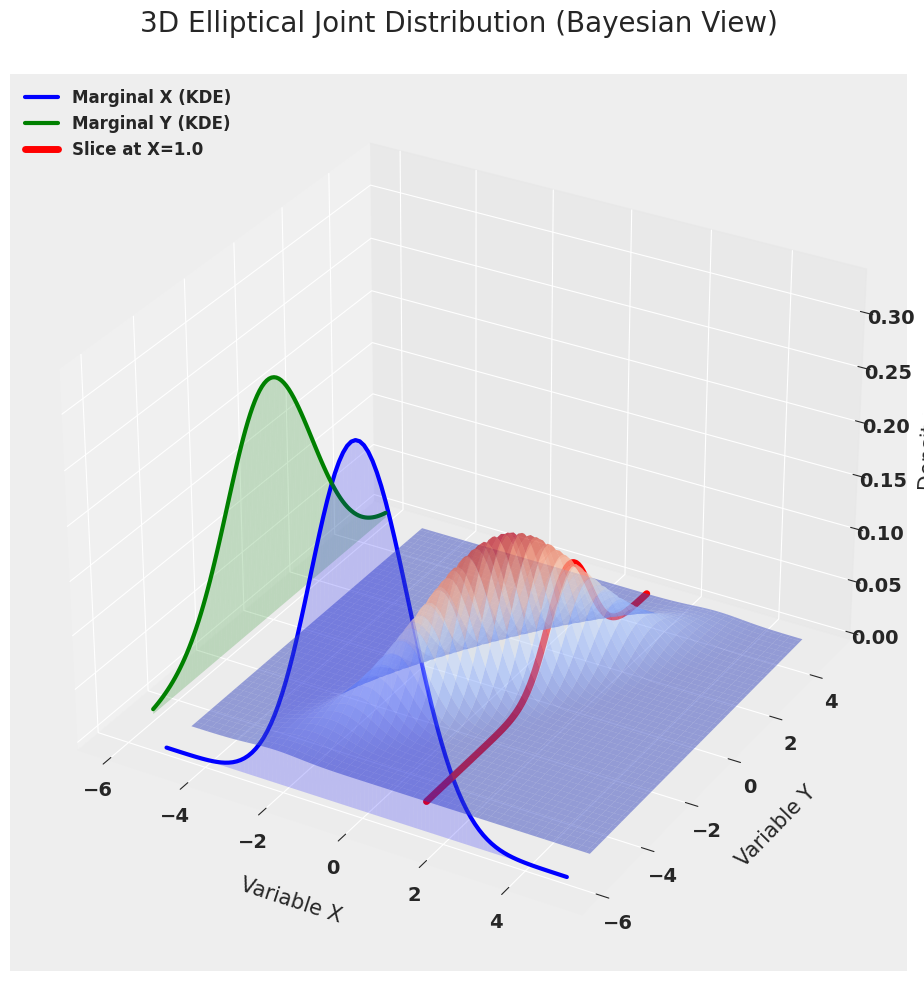

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. 환경 설정 (글자 크기 상향)
plt.rcParams.update({'font.size': 13, 'font.weight': 'bold'})

# 2. 공분산 설정으로 타원형 만들기
# 상관계수(rho)를 높일수록(예: 0.9) 타원이 더 얇고 길어집니다.
mean = np.array([0, 0])
rho = 0.85  # 상관계수
sigma_x, sigma_y = 1.2, 1.8
cov = np.array([[sigma_x**2, rho * sigma_x * sigma_y],
                [rho * sigma_x * sigma_y, sigma_y**2]])

rv = multivariate_normal(mean, cov)

# 3. Grid 생성
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
Z = rv.pdf(pos)

# 4. 시각화
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Joint PDF Surface (타원형 언덕)
surf = ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.5, antialiased=True)

# 5. 주변 분포 (Marginal) - 히스토그램 + KDE 스타일
dx = x[1] - x[0]
dy = y[1] - y[0]
fX = Z.sum(axis=0) * dy
fY = Z.sum(axis=1) * dx

# X축 Marginal (바닥면 벽) - Poly3DCollection 사용
y_offset_x = y.min() - 1
verts_x = []
for i in range(len(x) - 1):
    verts_x.append([(x[i], y_offset_x, 0), (x[i+1], y_offset_x, 0), (x[i+1], y_offset_x, fX[i+1]), (x[i], y_offset_x, fX[i])])
poly_x = Poly3DCollection(verts_x, alpha=0.2, facecolor='blue')
ax.add_collection3d(poly_x)
ax.plot(x, np.full_like(x, y_offset_x), fX, color='blue', lw=3, label='Marginal X (KDE)')

# Y축 Marginal (옆면 벽) - Poly3DCollection 사용
x_offset_y = x.min() - 1
verts_y = []
for i in range(len(y) - 1):
    verts_y.append([(x_offset_y, y[i], 0), (x_offset_y, y[i+1], 0), (x_offset_y, y[i+1], fY[i+1]), (x_offset_y, y[i], fY[i])])
poly_y = Poly3DCollection(verts_y, alpha=0.2, facecolor='green')
ax.add_collection3d(poly_y)
ax.plot(np.full_like(y, x_offset_y), y, fY, color='green', lw=3, label='Marginal Y (KDE)')

# 6. 조건부 분포 (X=x0 단면)
x0 = 1.0
ax.plot(np.full_like(y, x0), y, rv.pdf(np.column_stack([np.full_like(y, x0), y])),
        color='red', lw=5, label=f'Slice at X={x0}')

# 7. 스타일링
ax.set_xlabel('Variable X', labelpad=15)
ax.set_ylabel('Variable Y', labelpad=15)
ax.set_zlabel('Density', labelpad=10)
ax.set_title('3D Elliptical Joint Distribution (Bayesian View)', fontsize=20, pad=30)
ax.legend(loc='upper left', fontsize=12)

# 각도 조절 (타원형이 잘 보이도록)
ax.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3596/2413273076.py:71: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


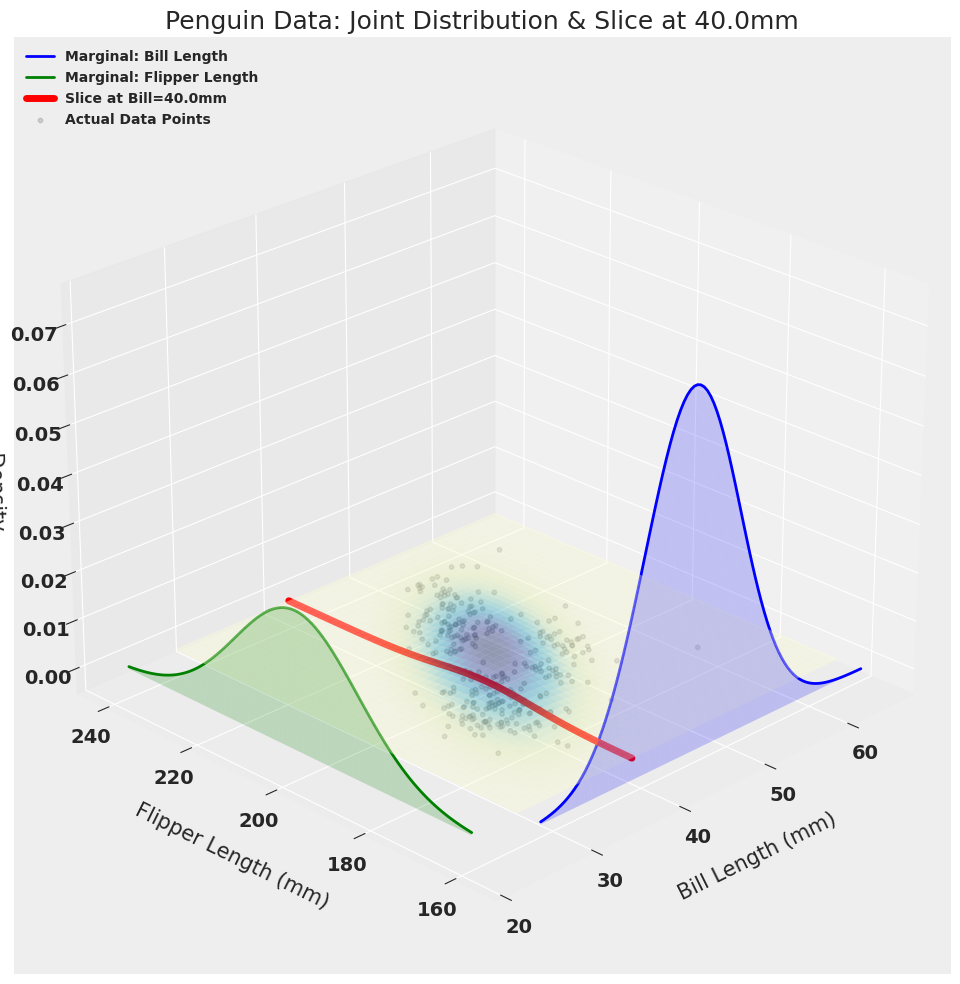

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. 데이터 로드 및 통계량 계산
penguins = sns.load_dataset("penguins").dropna()
# X: 부리 길이(bill_length), Y: 플리퍼 길이(flipper_length)
data_x = penguins['bill_length_mm']
data_y = penguins['flipper_length_mm']

mean = [data_x.mean(), data_y.mean()]
cov = np.cov(data_x, data_y)
rv = multivariate_normal(mean, cov)

# 2. 환경 설정
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})

# 3. Grid 생성 (데이터 범위에 맞게 조정)
x_range = np.linspace(data_x.min() - 5, data_x.max() + 5, 100)
y_range = np.linspace(data_y.min() - 10, data_y.max() + 10, 100)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y))
Z = rv.pdf(pos)

# 4. 시각화
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Joint PDF Surface
surf = ax.plot_surface(X, Y, Z, cmap='YlGnBu', alpha=0.4, antialiased=True)

# 5. 주변 분포 (Marginal) 시각화
dx = x_range[1] - x_range[0]
dy = y_range[1] - y_range[0]
fX = Z.sum(axis=0) * dy
fY = Z.sum(axis=1) * dx

# X축 Marginal (Bill Length)
y_off = y_range.min() - 5
verts_x = [[(x_range[i], y_off, 0), (x_range[i+1], y_off, 0),
            (x_range[i+1], y_off, fX[i+1]), (x_range[i], y_off, fX[i])] for i in range(len(x_range)-1)]
ax.add_collection3d(Poly3DCollection(verts_x, alpha=0.2, facecolor='blue'))
ax.plot(x_range, np.full_like(x_range, y_off), fX, color='blue', lw=2, label='Marginal: Bill Length')

# Y축 Marginal (Flipper Length)
x_off = x_range.min() - 5
verts_y = [[(x_off, y_range[i], 0), (x_off, y_range[i+1], 0),
            (x_off, y_range[i+1], fY[i+1]), (x_off, y_range[i], fY[i])] for i in range(len(y_range)-1)]
ax.add_collection3d(Poly3DCollection(verts_y, alpha=0.2, facecolor='green'))
ax.plot(np.full_like(y_range, x_off), y_range, fY, color='green', lw=2, label='Marginal: Flipper Length')

# 6. 조건부 분포 (Bill Length = 40mm 단면)
x0 = 40.0
# 해당 지점에서의 Joint PDF 값 (단면 곡선)
z_slice = rv.pdf(np.column_stack([np.full_like(y_range, x0), y_range]))
ax.plot(np.full_like(y_range, x0), y_range, z_slice, color='red', lw=5, label=f'Slice at Bill={x0}mm')

# 7. 실제 데이터 포인트 추가 (바닥에 투영)
ax.scatter(data_x, data_y, 0, c='gray', s=10, alpha=0.3, label='Actual Data Points')

# 스타일링
ax.set_xlabel('Bill Length (mm)', labelpad=15)
ax.set_ylabel('Flipper Length (mm)', labelpad=15)
ax.set_zlabel('Density', labelpad=10)
ax.set_title(f'Penguin Data: Joint Distribution & Slice at {x0}mm', fontsize=18)
ax.legend(loc='upper left', fontsize=10)

ax.view_init(elev=25, azim=-135) # 각도를 조절하여 단면이 잘 보이게 설정
plt.tight_layout()
plt.show()

/tmp/ipykernel_3596/1943750728.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


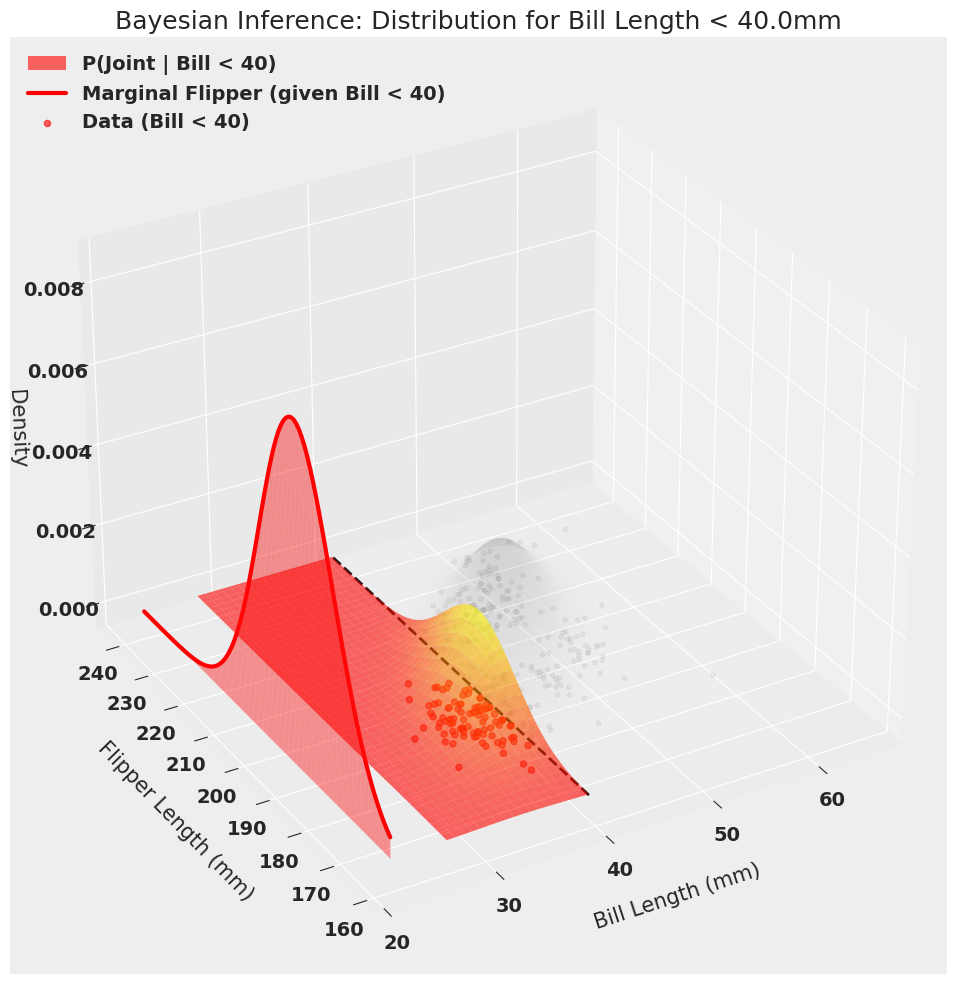

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. 데이터 로드 및 통계량 계산
penguins = sns.load_dataset("penguins").dropna()
data_x = penguins['bill_length_mm']
data_y = penguins['flipper_length_mm']

mean = [data_x.mean(), data_y.mean()]
cov = np.cov(data_x, data_y)
rv = multivariate_normal(mean, cov)

# 2. 환경 설정
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})

# 3. Grid 생성
x_range = np.linspace(data_x.min() - 5, data_x.max() + 5, 100)
y_range = np.linspace(data_y.min() - 10, data_y.max() + 10, 100)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y))
Z = rv.pdf(pos)

# 4. 시각화
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Joint PDF Surface (전체 분포는 아주 흐리게)
ax.plot_surface(X, Y, Z, cmap='Greys', alpha=0.1, antialiased=True)

# 5. 조건부 영역 시각화 (X < 40)
x_limit = 40.0
# X < 40 인 영역만 추출하여 강조
X_sub = X[X < x_limit].reshape(-1, len(y_range)) # 재구조화는 단순화를 위해 생략 가능하나 시각화용 마스크 생성
mask = X < x_limit
Z_cond = np.where(mask, Z, np.nan) # 40 이상은 그리지 않음

# X < 40 영역의 표면만 진하게 표시
surf_cond = ax.plot_surface(X, Y, Z_cond, cmap='autumn', alpha=0.6, antialiased=True, label='P(Joint | Bill < 40)')

# 6. X < 40 구간의 Marginal Y (이 구간 펭귄들의 플리퍼 분포)
# X < 40 영역에 대해서만 X축 방향으로 적분(합산)
fX_sub = Z[:, x_range < x_limit].sum(axis=1) * (x_range[1] - x_range[0])
# 시각적 비교를 위해 정규화(선택 사항)
x_off = x_range.min() - 5
verts_y_cond = [[(x_off, y_range[i], 0), (x_off, y_range[i+1], 0),
                 (x_off, y_range[i+1], fX_sub[i+1]), (x_off, y_range[i], fX_sub[i])] for i in range(len(y_range)-1)]
ax.add_collection3d(Poly3DCollection(verts_y_cond, alpha=0.4, facecolor='red'))
ax.plot(np.full_like(y_range, x_off), y_range, fX_sub, color='red', lw=3, label='Marginal Flipper (given Bill < 40)')

# 7. 실제 데이터 포인트 (조건에 맞는 데이터만 강조)
cond_indices = data_x < x_limit
ax.scatter(data_x[cond_indices], data_y[cond_indices], 0, c='red', s=20, alpha=0.6, label='Data (Bill < 40)')
ax.scatter(data_x[~cond_indices], data_y[~cond_indices], 0, c='gray', s=10, alpha=0.1)

# 스타일링
ax.set_xlabel('Bill Length (mm)', labelpad=15)
ax.set_ylabel('Flipper Length (mm)', labelpad=15)
ax.set_zlabel('Density', labelpad=10)
ax.set_title(f'Bayesian Inference: Distribution for Bill Length < {x_limit}mm', fontsize=18)
ax.legend(loc='upper left')

# 경계선 표시 (X=40 지점에 수직 벽)
ax.plot([x_limit, x_limit], [y_range.min(), y_range.max()], [0, 0], color='black', linestyle='--', lw=2)

ax.view_init(elev=30, azim=-120)
plt.tight_layout()
plt.show()

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

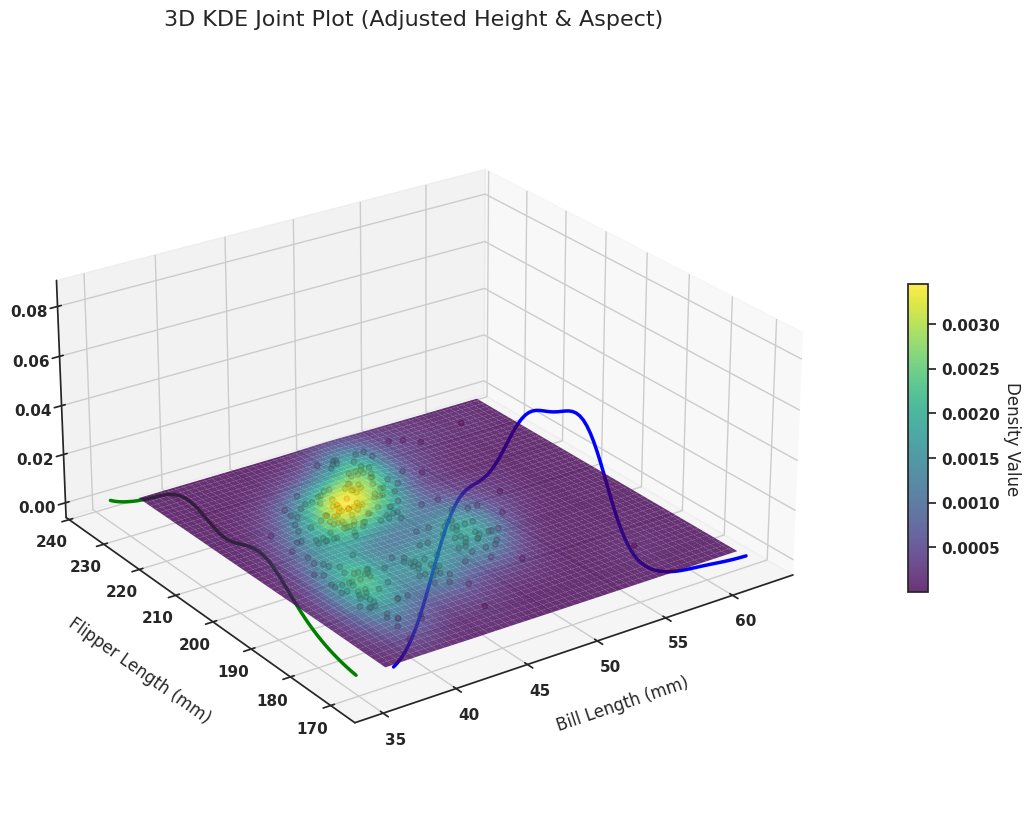

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# 1. 데이터 로드 및 필터링 (Bill Length >= 40)
penguins = sns.load_dataset("penguins").dropna()
filtered_penguins = penguins[penguins['bill_length_mm'] >= 40]

x_data = filtered_penguins['bill_length_mm'].values
y_data = filtered_penguins['flipper_length_mm'].values

# 2. KDE 계산
values = np.vstack([x_data, y_data])
kernel = gaussian_kde(values)

# 3. Grid 설정
x_min, x_max = x_data.min() - 3, x_data.max() + 3
y_min, y_max = y_data.min() - 5, y_data.max() + 5
X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

positions = np.vstack([X.ravel(), Y.ravel()])
Z = kernel(positions).reshape(X.shape)

# 4. 시각화 설정
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
plt.rcParams.update({'font.size': 11, 'font.weight': 'bold'})

# --- 핵심 수정: Z축 높이 배율 조정 ---
# set_box_aspect를 사용하여 x, y, z축의 물리적 길이를 조정합니다.
# z=0.5로 설정하여 언덕의 높이를 절반 정도로 낮게 만듭니다.
ax.set_box_aspect((1, 1, 0.5))

# 4-1. KDE Surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, antialiased=True, edgecolor='none')

# 5. Marginal 분포 (투영)
dx = (x_max - x_min) / 100
dy = (y_max - y_min) / 100
fX = Z.sum(axis=0) * dy
fY = Z.sum(axis=1) * dx

ax.plot(np.linspace(x_min, x_max, 100), np.full(100, y_min-2), fX, color='blue', lw=2.5, label='Bill KDE')
ax.plot(np.full(100, x_min-2), np.linspace(y_min, y_max, 100), fY, color='green', lw=2.5, label='Flipper KDE')

# 6. 산점도
ax.scatter(x_data, y_data, 0, c='red', edgecolors='black', s=15, alpha=0.4)

# 7. 스타일링 (Y축 라벨 가독성 강화)
ax.set_xlabel('Bill Length (mm)', labelpad=15, fontsize=12)
ax.set_ylabel('Flipper Length (mm)', labelpad=20, fontsize=12) # labelpad를 늘려 겹침 방지
ax.set_zlabel('Density', labelpad=10, fontsize=12)
ax.set_title('3D KDE Joint Plot (Adjusted Height & Aspect)', fontsize=16, pad=20)

# 컬러바 설정
cbar = fig.colorbar(surf, ax=ax, shrink=0.4, aspect=15, pad=0.1)
cbar.set_label('Density Value', rotation=270, labelpad=15)

# --- 핵심 수정: 시점 조정 ---
# azim(방위각)을 조정하여 Y축 글자가 정면 근처에 오도록 설정합니다.
ax.view_init(elev=25, azim=-125)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3596/1140522135.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


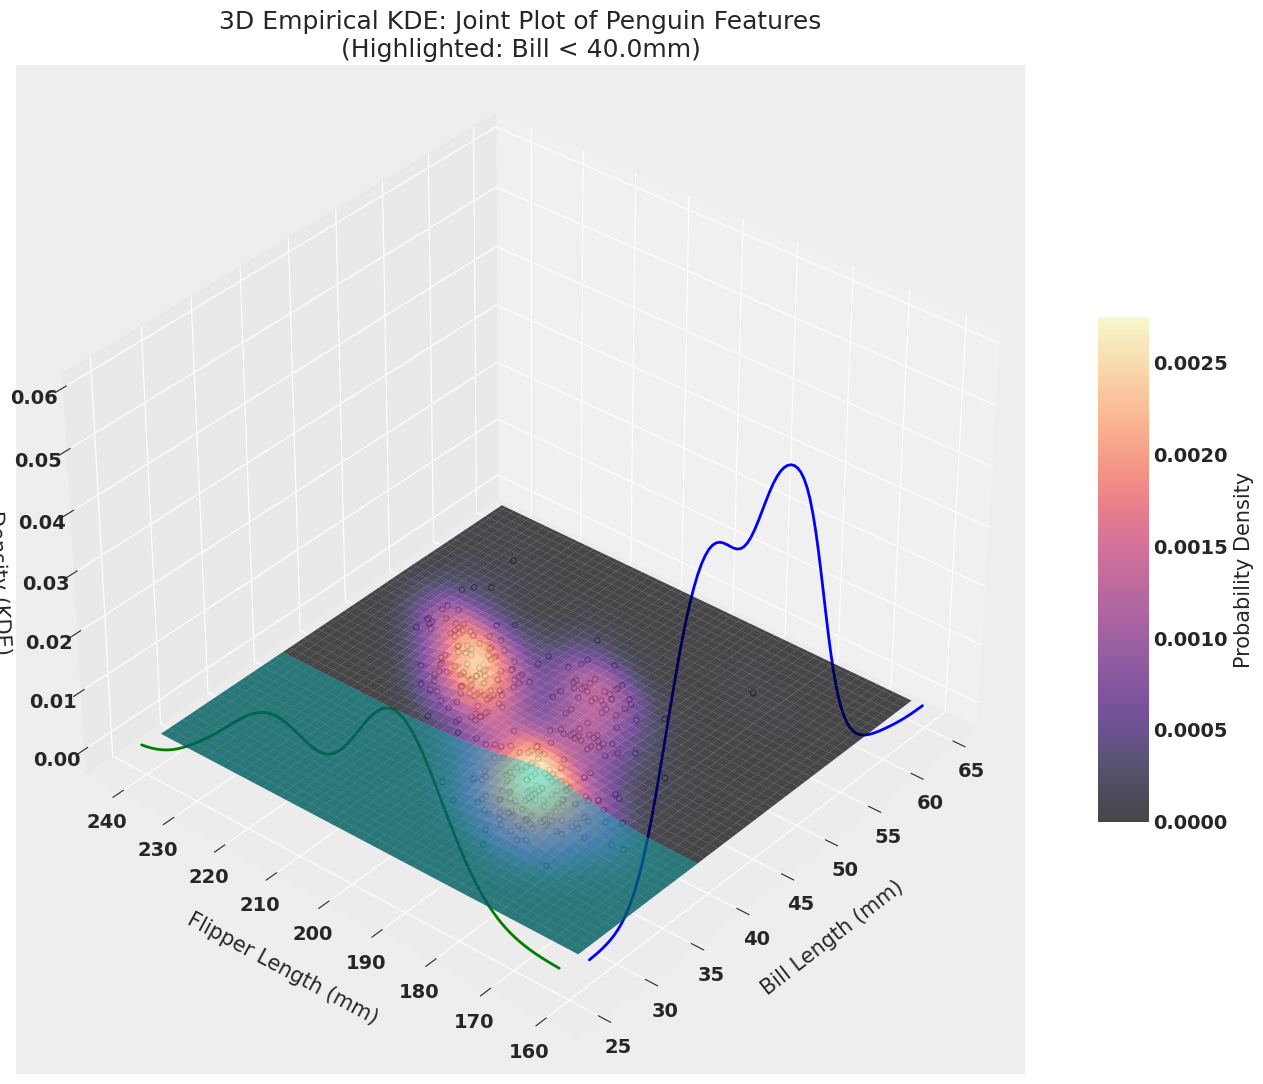

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 1. 데이터 로드 및 결측치 제거
penguins = sns.load_dataset("penguins").dropna()
x_data = penguins['bill_length_mm'].values
y_data = penguins['flipper_length_mm'].values

# 2. KDE 계산 (실제 데이터의 밀도를 추정)
values = np.vstack([x_data, y_data])
kernel = gaussian_kde(values)

# 3. Grid 설정 (데이터 분포 범위에 맞춤)
x_min, x_max = x_data.min() - 5, x_data.max() + 5
y_min, y_max = y_data.min() - 10, y_data.max() + 10
X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# 모든 Grid 포인트에서의 밀도(Z) 계산
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kernel(positions).reshape(X.shape)

# 4. 시각화 설정
fig = plt.figure(figsize=(15, 11))
ax = fig.add_subplot(111, projection='3d')
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})

# 4-1. KDE Surface (메인 언덕)
# cmap='viridis'나 'magma'가 밀도 차이를 보여주기에 좋습니다.
surf = ax.plot_surface(X, Y, Z, cmap='magma', alpha=0.7, antialiased=True, edgecolor='none')

# 4-2. X < 40 조건부 영역 강조 (투명한 벽면)
x_limit = 40.0
Z_mask = np.where(X < x_limit, Z, np.nan)
ax.plot_surface(X, Y, Z_mask, color='cyan', alpha=0.4, zorder=10) # 40 미만 영역 색상 반전

# 5. Marginal 분포 (옆면 투영)
dx = (x_max - x_min) / 100
dy = (y_max - y_min) / 100
fX = Z.sum(axis=0) * dy
fY = Z.sum(axis=1) * dx

# 바닥면 X-Marginal (Bill Length)
ax.plot(np.linspace(x_min, x_max, 100), np.full(100, y_min-2), fX, color='blue', lw=2, label='Bill KDE')
# 옆면 Y-Marginal (Flipper Length)
ax.plot(np.full(100, x_min-2), np.linspace(y_min, y_max, 100), fY, color='green', lw=2, label='Flipper KDE')

# 6. 실제 데이터 산점도 (바닥 투영)
# 밀도에 따라 점의 색상을 다르게 하면 더 KDE 느낌이 납니다.
ax.scatter(x_data, y_data, 0, c='white', edgecolors='black', s=15, alpha=0.4, label='Penguin Samples')

# 7. 스타일링 및 각도
ax.set_xlabel('Bill Length (mm)', labelpad=15)
ax.set_ylabel('Flipper Length (mm)', labelpad=15)
ax.set_zlabel('Density (KDE)', labelpad=10)
ax.set_title(f'3D Empirical KDE: Joint Plot of Penguin Features\n(Highlighted: Bill < {x_limit}mm)', fontsize=18)

# --- FIX: Move plt.tight_layout() before fig.colorbar() ---
plt.tight_layout()

# 컬러바 추가 (밀도 직관성)
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Probability Density')

ax.view_init(elev=35, azim=-140)
plt.show()

/tmp/ipykernel_3596/3706963757.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


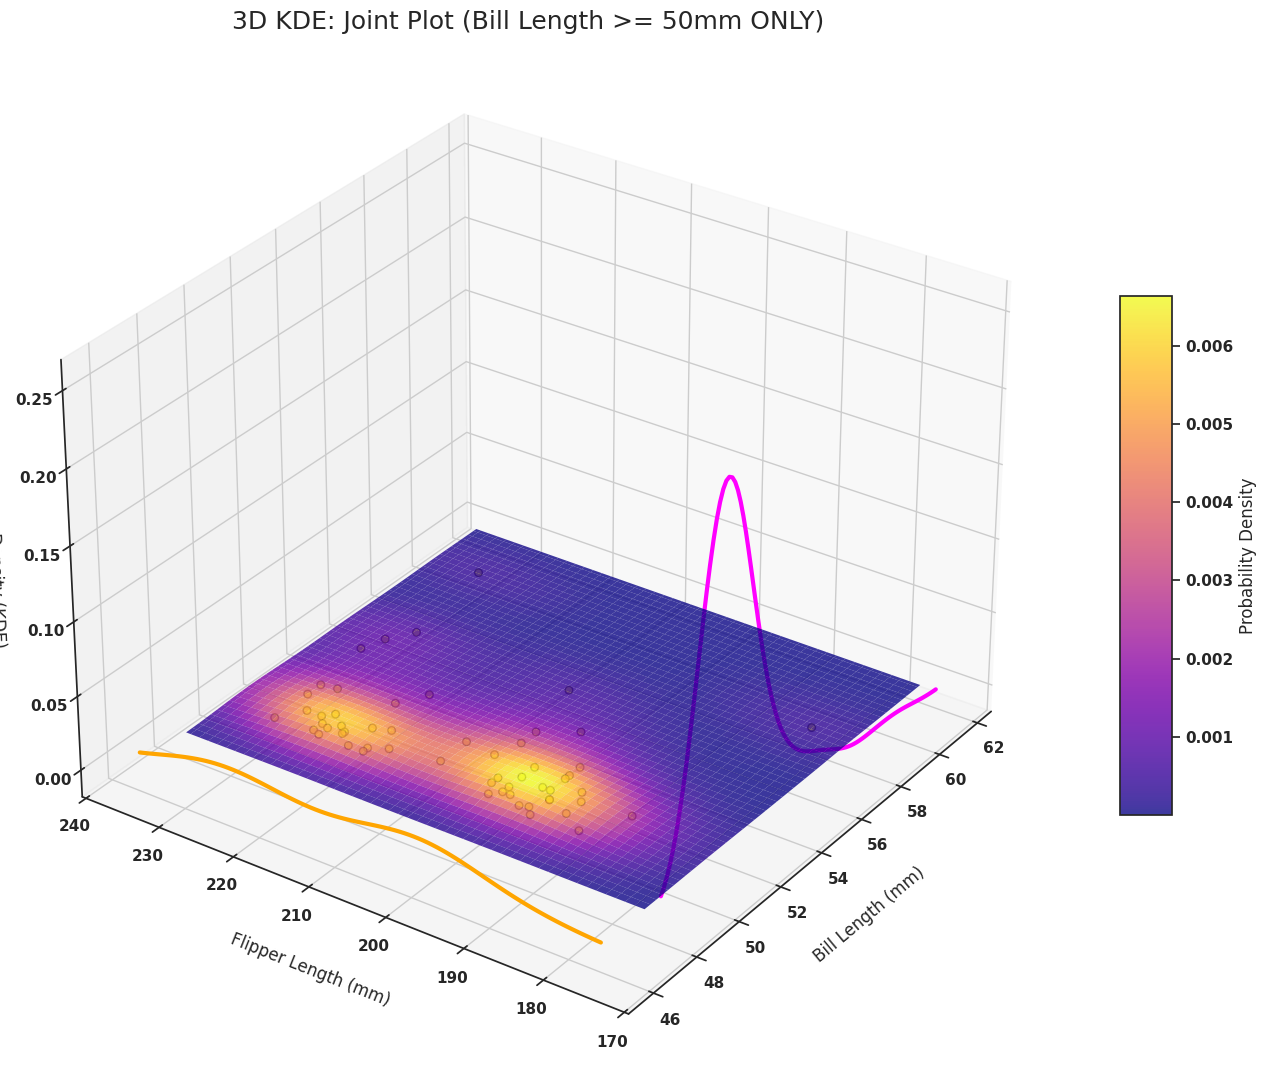

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# 1. 데이터 로드 및 필터링 (Bill Length >= 50)
penguins = sns.load_dataset("penguins").dropna()
# 부리 길이가 50mm 이상인 데이터만 추출
filtered_penguins = penguins[penguins['bill_length_mm'] >= 50]

x_data = filtered_penguins['bill_length_mm'].values
y_data = filtered_penguins['flipper_length_mm'].values

# 2. KDE 계산 (필터링된 50mm+ 데이터로 밀도 추정)
values = np.vstack([x_data, y_data])
kernel = gaussian_kde(values)

# 3. Grid 설정 (50mm 이상의 범위에 최적화)
x_min, x_max = x_data.min() - 2, x_data.max() + 2
y_min, y_max = y_data.min() - 5, y_data.max() + 5
X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

positions = np.vstack([X.ravel(), Y.ravel()])
Z = kernel(positions).reshape(X.shape)

# 4. 시각화 설정
fig = plt.figure(figsize=(15, 11))
ax = fig.add_subplot(111, projection='3d')
plt.rcParams.update({'font.size': 12, 'font.weight': 'bold'})

# 4-1. KDE Surface (50mm 이상의 데이터 언덕)
# 밀도가 더 집중되므로 'plasma' 맵으로 강렬하게 표현해봅니다.
surf = ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.8, antialiased=True, edgecolor='none')

# 5. Marginal 분포 (50mm+ 기준 투영)
dx = (x_max - x_min) / 100
dy = (y_max - y_min) / 100
fX = Z.sum(axis=0) * dy
fY = Z.sum(axis=1) * dx

# X-Marginal (Bill Length >= 50)
ax.plot(np.linspace(x_min, x_max, 100), np.full(100, y_min-2), fX, color='magenta', lw=3, label='Bill KDE (>=50)')
# Y-Marginal (Flipper Length)
ax.plot(np.full(100, x_min-2), np.linspace(y_min, y_max, 100), fY, color='orange', lw=3, label='Flipper KDE')

# 6. 필터링된 데이터 산점도 (바닥 투영)
ax.scatter(x_data, y_data, 0, c='yellow', edgecolors='black', s=30, alpha=0.6, label='Samples (>= 50mm)')

# 7. 스타일링 및 각도
ax.set_xlabel('Bill Length (mm)', labelpad=15)
ax.set_ylabel('Flipper Length (mm)', labelpad=15)
ax.set_zlabel('Density (KDE)', labelpad=10)
ax.set_title('3D KDE: Joint Plot (Bill Length >= 50mm ONLY)', fontsize=18)

plt.tight_layout()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Probability Density')

# 단면이 더 잘 보이도록 시점 조정
ax.view_init(elev=30, azim=-145)
plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:1766: UserWarning: The figure layout has changed to tight
  f.tight_layout()


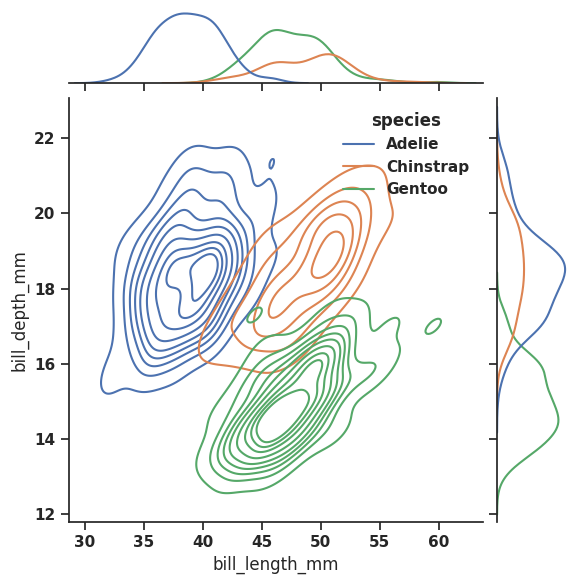

In [21]:
import seaborn as sns
sns.set_theme(style="ticks")

# Load the penguins dataset
penguins = sns.load_dataset("penguins")

# Show the joint distribution using kernel density estimation
g = sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm",
    hue="species",
    kind="kde",
)